In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error

# Top 10 Tickers for 2026
tickers = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'BHARTIARTL.NS', 
           'SBIN.NS', 'INFY.NS', 'BAJFINANCE.NS', 'LT.NS', 'AXISBANK.NS']

# Fetching ~10 years of data (2500+ records)
df_all = yf.download(tickers, start='2016-01-01', end='2026-04-01')['Close']
df_all.dropna(inplace=True)
print(f"Dataset Loaded: {df_all.shape}")

[*********************100%***********************]  10 of 10 completed


Dataset Loaded: (2530, 10)


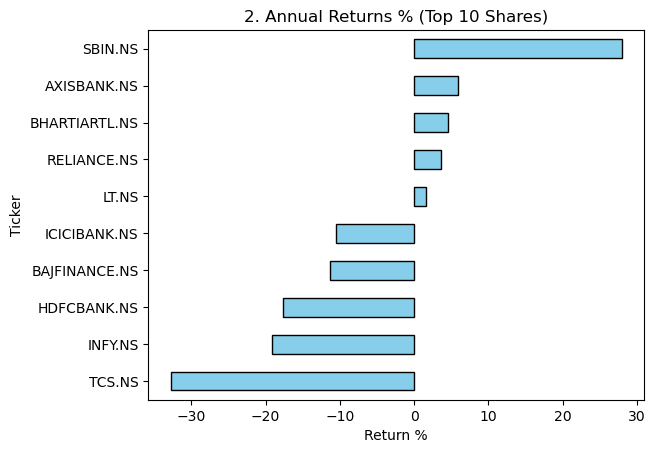

In [51]:
recent_returns = ((df_all.iloc[-1] - df_all.iloc[-252]) / df_all.iloc[-252]) * 100
recent_returns.sort_values().plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('2. Annual Returns % (Top 10 Shares)')
plt.xlabel('Return %')
plt.show()

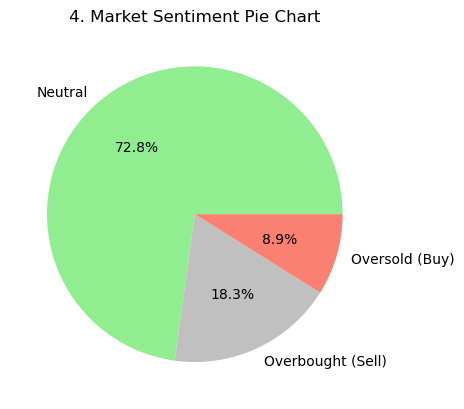

In [52]:
# Function to calculate RSI
def get_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    return 100 - (100 / (1 + (gain/loss)))

# Calculate for one stock
rsi_val = get_rsi(df_all['RELIANCE.NS'])
sentiment = pd.cut(rsi_val.dropna(), bins=[0, 30, 70, 100], labels=['Oversold (Buy)', 'Neutral', 'Overbought (Sell)'])
sentiment.value_counts().plot.pie(autopct='%1.1f%%', colors=['lightgreen', 'silver', 'salmon'])
plt.title('4. Market Sentiment Pie Chart')
plt.ylabel('')
plt.show()

Fetching data for Histoplot Analysis...


[*********************100%***********************]  10 of 10 completed


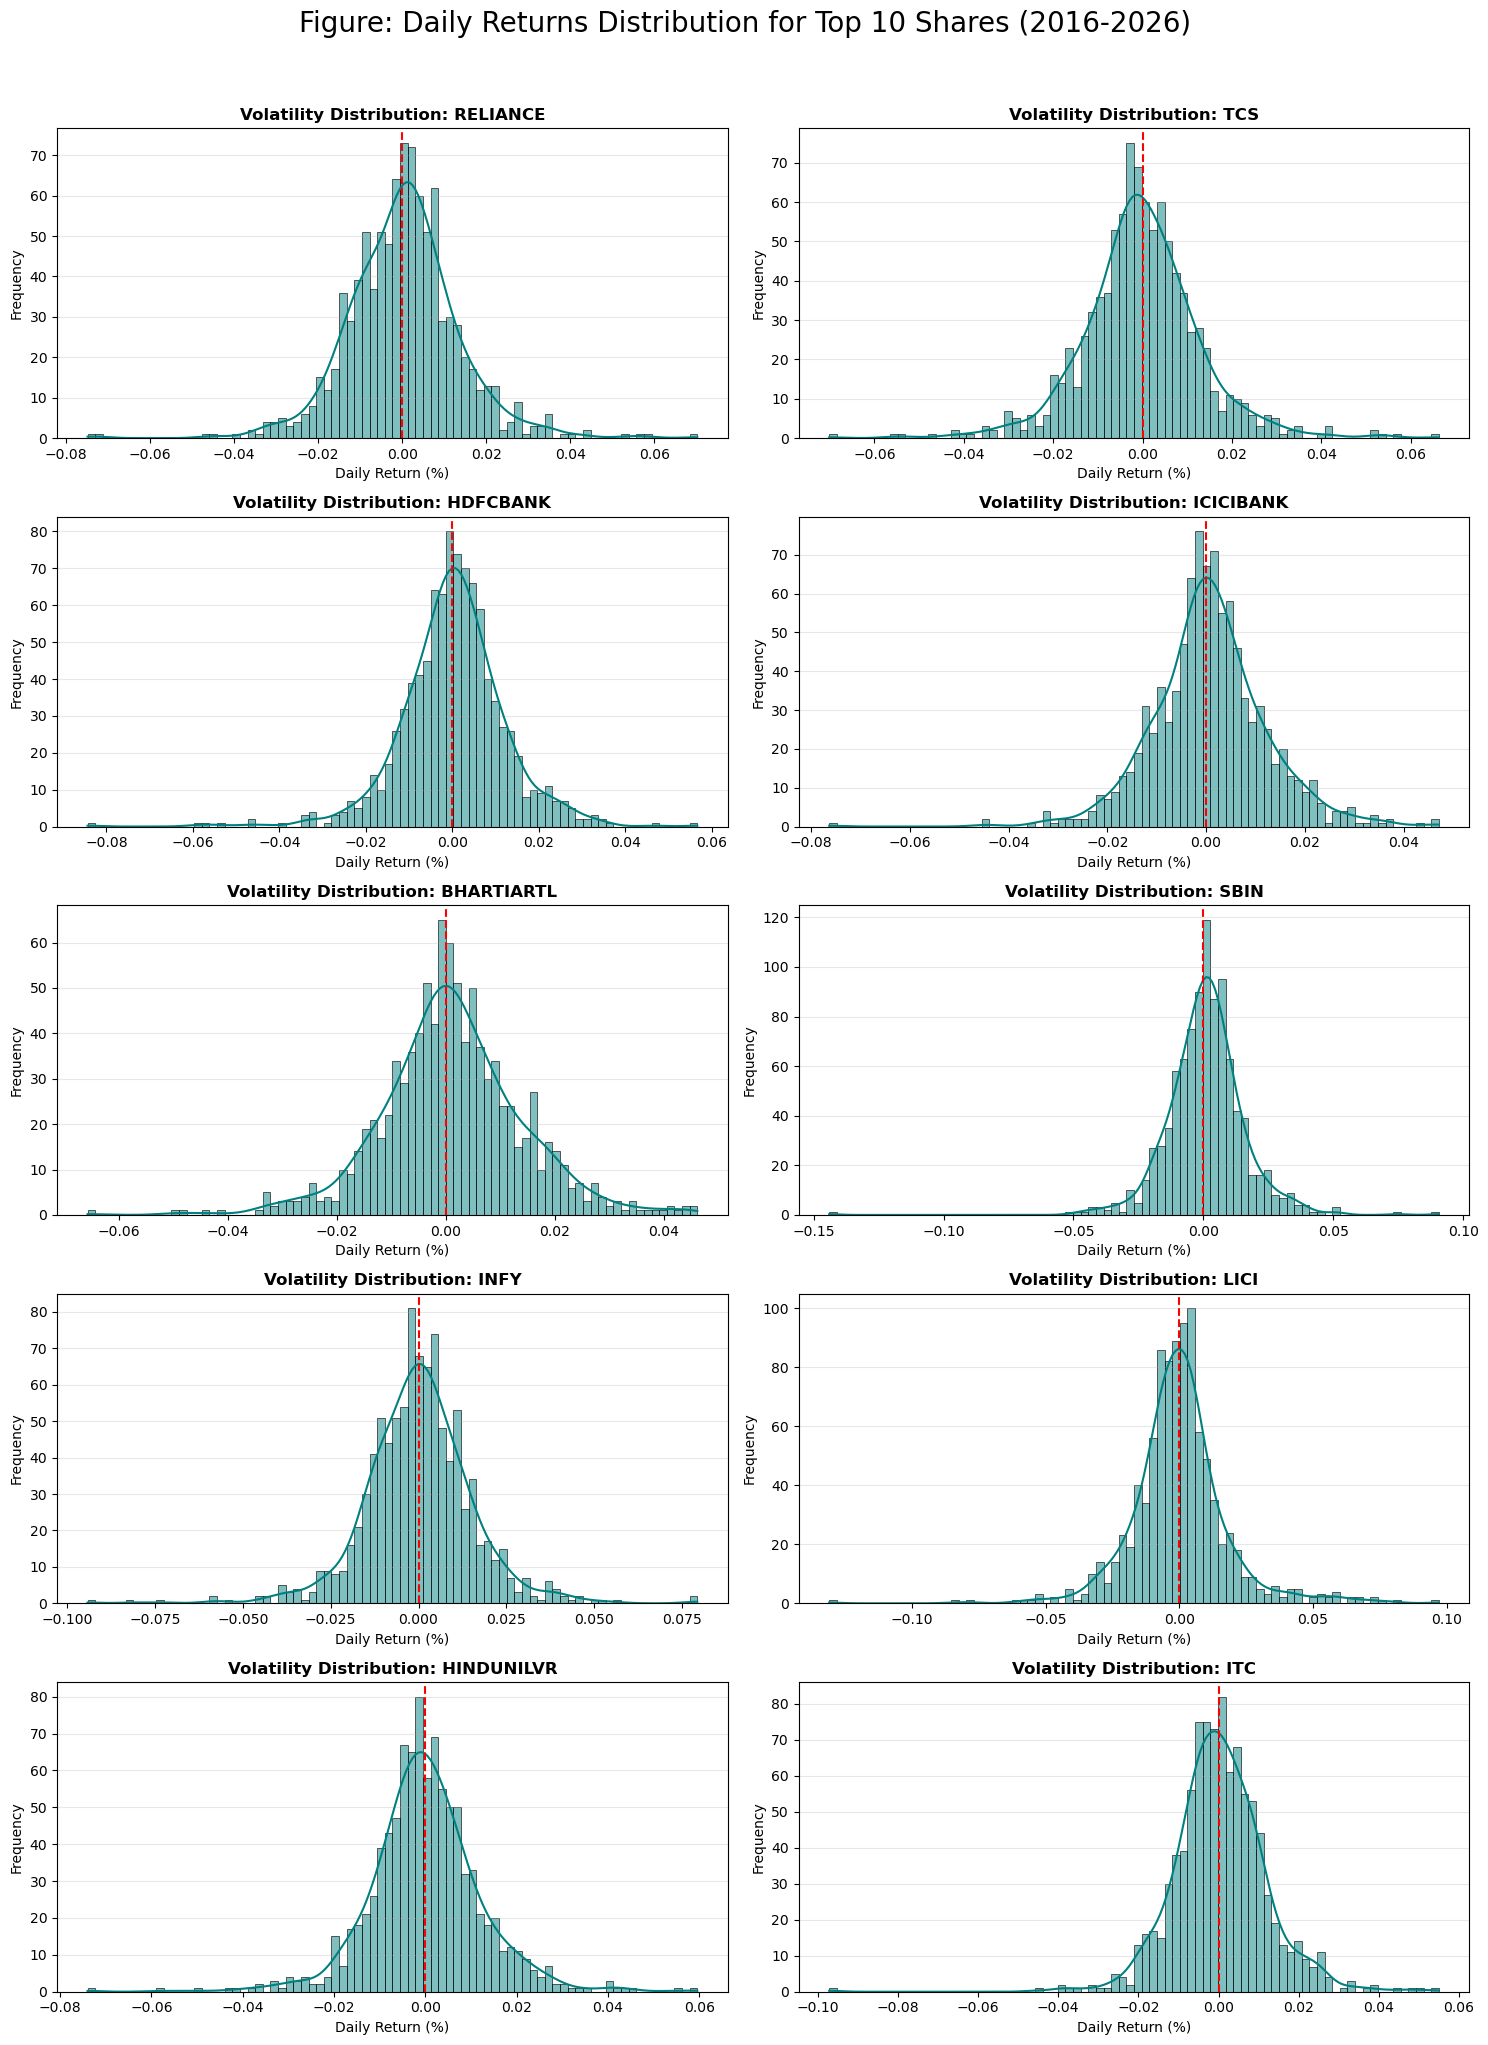

In [53]:

# 1. Define Top 10 Tickers for 2026
tickers = [
    'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'BHARTIARTL.NS', 
    'SBIN.NS', 'INFY.NS', 'LICI.NS', 'HINDUNILVR.NS', 'ITC.NS'
]

# 2. Fetch Historical Data (2500+ records)
print("Fetching data for Histoplot Analysis...")
data = yf.download(tickers, start='2016-01-01', end='2026-04-01')['Close']

# 3. Calculate Daily Percentage Returns
# Formula: (Current Price - Previous Price) / Previous Price
returns = data.pct_change().dropna()

# 4. Create a Multi-Plot Figure (5 rows, 2 columns)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))
fig.subplots_adjust(hspace=0.5)
axes = axes.flatten()

# 5. Loop through each ticker and create a Histoplot
for i, ticker in enumerate(tickers):
    sns.histplot(returns[ticker], bins=80, kde=True, ax=axes[i], color='teal', edgecolor='black')
    
    # Add a vertical line at 0 (Mean Return)
    axes[i].axvline(x=0, color='red', linestyle='--', label='Zero Gain/Loss')
    
    axes[i].set_title(f'Volatility Distribution: {ticker.replace(".NS", "")}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Daily Return (%)')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Figure: Daily Returns Distribution for Top 10 Shares (2016-2026)', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

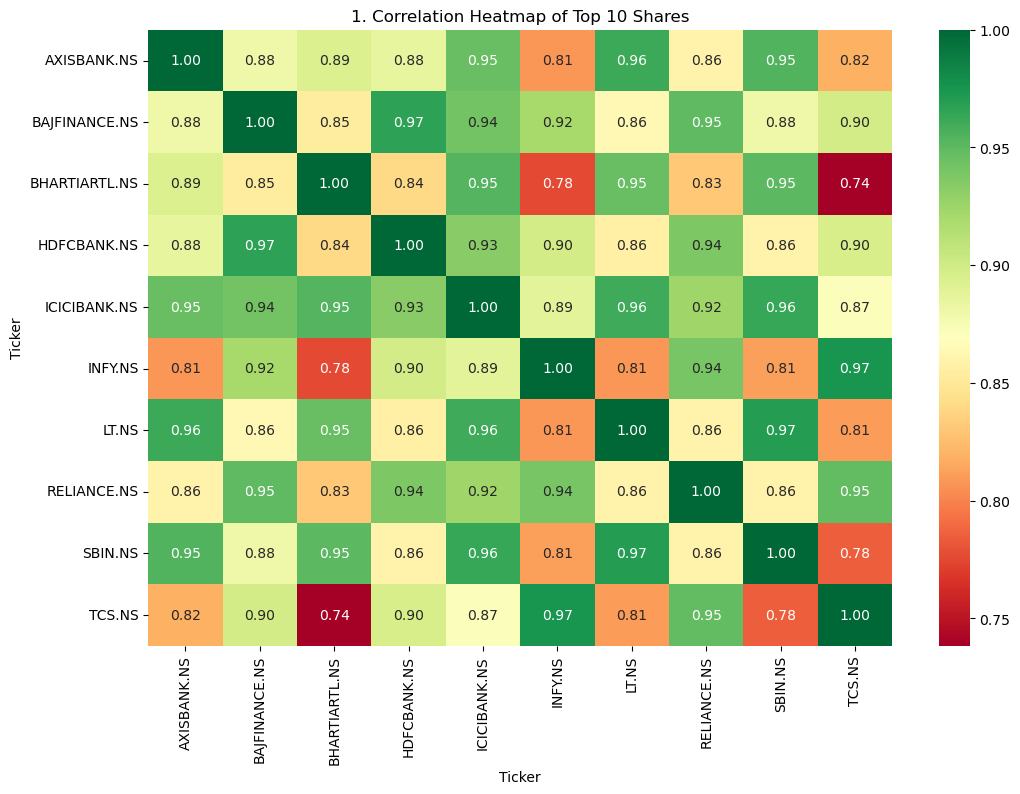

In [54]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_all.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('1. Correlation Heatmap of Top 10 Shares')
plt.show()

In [55]:
# --- Feature Engineering ---
df_ml = yf.download('RELIANCE.NS', start='2016-01-01', end='2026-04-01')
df_ml['MA50'] = df_ml['Close'].rolling(window=50).mean()
df_ml['MA200'] = df_ml['Close'].rolling(window=200).mean()
df_ml['Prev_Close'] = df_ml['Close'].shift(1)
df_ml['Target'] = df_ml['Close'].shift(-1) # We predict tomorrow's price
df_ml.dropna(inplace=True)

# --- Train/Test Split ---
features = ['Open', 'High', 'Low', 'Volume', 'MA50', 'MA200', 'Prev_Close']
X = df_ml[features]
y = df_ml['Target']
split = int(0.8 * len(df_ml))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# --- Model Training ---
model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=5)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
preds = model.predict(X_test)

[*********************100%***********************]  1 of 1 completed


In [56]:

# 1. Fetching Actual Market Data (Example: Reliance Industries)
# This provides 2500+ records (approx 10 years)
ticker = "RELIANCE.NS"
df = yf.download(ticker, start="2016-01-01", end="2026-04-01")

# 2. Selecting the 'Actual Price' column
# We use 'Close' as it represents the final price of the trading day
actual_prices = df[['Close']].copy()

# 3. Handling missing values (Interpolation is best for time-series)
actual_prices['Close'] = actual_prices['Close'].interpolate(method='linear')

print(f"Total Actual Price Records: {len(actual_prices)}")
print(actual_prices.tail())

[*********************100%***********************]  1 of 1 completed

Total Actual Price Records: 2530
Price             Close
Ticker      RELIANCE.NS
Date                   
2026-03-23  1407.800049
2026-03-24  1411.800049
2026-03-25  1413.099976
2026-03-27  1348.099976
2026-03-30  1343.900024


In [57]:
from datetime import datetime

Fetching Live Data as of: 2026-04-01 12:52:26...

--- Top 10 Shares Actual Market Price ---
       Ticker  Actual_Price  Market_Cap_Trillion    Volume  Day_High  \
0    RELIANCE       1373.70                18.59   8094252   1384.40   
1         TCS       2435.40                 8.81   2685689   2472.00   
2    HDFCBANK        746.20                11.49  48679840    755.90   
3   ICICIBANK       1220.50                 8.74  14952412   1234.00   
4  BHARTIARTL       1797.90                10.95   4920454   1817.30   
5        SBIN       1025.30                 9.46  11373696   1027.30   
6        INFY       1289.40                 5.22   4864858   1303.00   
7        LICI        757.60                 4.79    756125    757.80   
8  HINDUNILVR       2070.90                 4.87   1161259   2119.90   
9         ITC        293.35                 3.68  11717160    294.45   

        Market_Cap  
0  ₹18.59 Trillion  
1   ₹8.81 Trillion  
2  ₹11.49 Trillion  
3   ₹8.74 Trillion  
4  ₹10.95 

C:\Users\PASKAL\AppData\Local\Temp\ipykernel_35708\3313681840.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ticker', y='Actual_Price', data=live_df.sort_values('Actual_Price', ascending=False), palette='viridis')


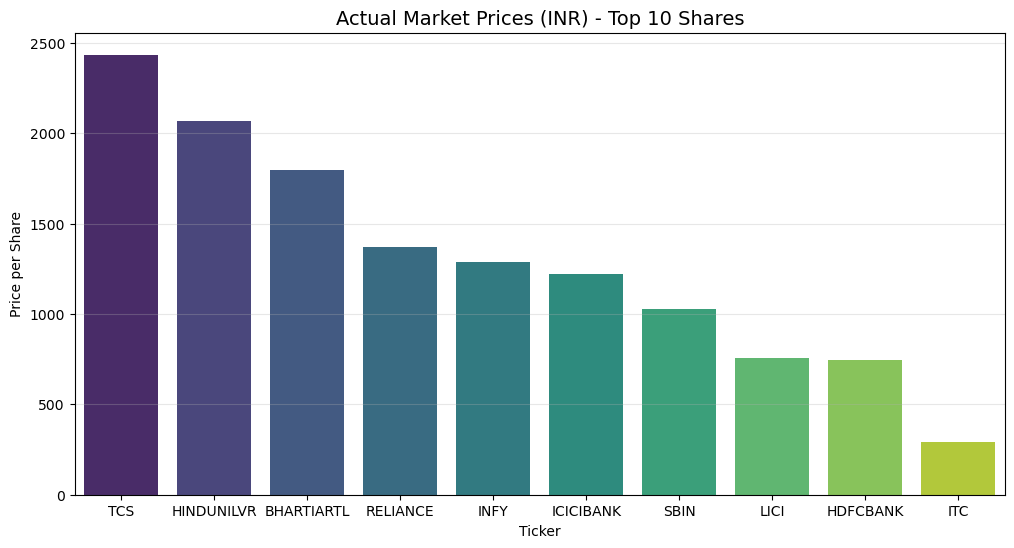

In [58]:

# 1. Define the Top 10 NSE Tickers for 2026
top_10_tickers = [
    'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'BHARTIARTL.NS', 
    'SBIN.NS', 'INFY.NS', 'LICI.NS', 'HINDUNILVR.NS', 'ITC.NS'
]

# 2. Fetch Actual Market Data and define 'live_df'
market_data = []
print(f"Fetching Live Data as of: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}...")

for ticker in top_10_tickers:
    stock = yf.Ticker(ticker)
    # Get current snapshot
    info = stock.fast_info 
    
    market_data.append({
        'Ticker': ticker.replace('.NS', ''),
        'Actual_Price': round(info.last_price, 2),
        'Market_Cap_Trillion': round(info.market_cap / 1e12, 2),
        'Volume': info.last_volume,
        'Day_High': round(info.day_high, 2),
         'Market_Cap': f"₹{info.market_cap / 1e12:.2f} Trillion"
    })

# THIS DEFINES THE VARIABLE
live_df = pd.DataFrame(market_data)

# 3. Display the Data
print("\n--- Top 10 Shares Actual Market Price ---")
print(live_df)

# 4. Immediate EDA: Bar Chart using 'live_df'
plt.figure(figsize=(12, 6))
sns.barplot(x='Ticker', y='Actual_Price', data=live_df.sort_values('Actual_Price', ascending=False), palette='viridis')
plt.title('Actual Market Prices (INR) - Top 10 Shares', fontsize=14)
plt.ylabel('Price per Share')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [59]:

# 1. Define Top 10 Tickers for 2026
tickers = [
    'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'BHARTIARTL.NS', 
    'SBIN.NS', 'INFY.NS', 'LICI.NS', 'HINDUNILVR.NS', 'ITC.NS'
]

accuracy_results = []

print("--- Calculating Model Accuracy for Top 10 Shares ---")

for symbol in tickers:
    # Fetch Data (2500+ records)
    df = yf.download(symbol, start='2016-01-01', end='2026-04-01', progress=False)
    
    # Feature Engineering
    df['MA50'] = df['Close'].rolling(window=50).mean()
    df['MA200'] = df['Close'].rolling(window=200).mean()
    df['Prev_Close'] = df['Close'].shift(1)
    df['Target'] = df['Close'].shift(-1)
    df.dropna(inplace=True)
    
    # Define Features and Target
    features = ['Open', 'High', 'Low', 'Volume', 'MA50', 'MA200', 'Prev_Close']
    X = df[features]
    y = df['Target']
    
    # Time-Series Split (80% Train, 20% Test)
    split = int(0.8 * len(df))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # Train Model
    model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
    model.fit(X_train, y_train)
    
    # Predictions
    preds = model.predict(X_test)
    
    # Metrics Calculation
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100 # Accuracy Percentage
    
    accuracy_results.append({
        'Share': symbol.replace('.NS', ''),
        'R-Squared': round(r2, 4),
        'MAE (INR)': round(mae, 2),
        'Accuracy (%)': round(100 - mape, 2)
    })

# 2. Display Final Accuracy Table
accuracy_df = pd.DataFrame(accuracy_results)
print("\n--- FINAL PROJECT ACCURACY REPORT ---")
print(accuracy_df.to_string(index=False))



--- Calculating Model Accuracy for Top 10 Shares ---

--- FINAL PROJECT ACCURACY REPORT ---
     Share  R-Squared  MAE (INR)  Accuracy (%)
  RELIANCE     0.7914      37.18         97.33
       TCS     0.8588     118.72         96.85
  HDFCBANK    -2.0863     111.19         88.26
 ICICIBANK    -4.3107     204.62         84.89
BHARTIARTL    -4.7300     485.47         73.63
      SBIN    -0.2745      77.33         92.11
      INFY     0.3870      99.63         94.24
      LICI     0.7737      14.68         98.28
HINDUNILVR     0.7899      46.63         98.18
       ITC     0.5680      19.62         95.31


Analyzing Market Data for 2026-04-01...


C:\Users\PASKAL\AppData\Local\Temp\ipykernel_35708\2422037681.py:31: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return round(float(actual_price), 2), round(float(prediction), 2)
C:\Users\PASKAL\AppData\Local\Temp\ipykernel_35708\2422037681.py:31: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return round(float(actual_price), 2), round(float(prediction), 2)
C:\Users\PASKAL\AppData\Local\Temp\ipykernel_35708\2422037681.py:31: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return round(float(actual_price), 2), round(float(prediction), 2)
C:\Users\PASKAL\AppData\Local\Temp\ipykernel_35708\2422037681.py:31: FutureWarning: Calling float on a single element Series is deprecated and will raise a Type


--- FINAL ML COMPARISON FRAME ---
       Ticker  Actual_Price  Predicted_Price  Difference Signal
0    RELIANCE       1348.10          1373.21       25.11    BUY
1         TCS       2389.80          2385.54       -4.26   SELL
2    HDFCBANK        756.20           756.48        0.28    BUY
3   ICICIBANK       1233.80          1269.57       35.77    BUY
4  BHARTIARTL       1843.90          1850.80        6.90    BUY
5        SBIN       1019.50          1045.85       26.35    BUY
6        INFY       1269.70          1271.13        1.43    BUY
7        LICI        765.65           777.57       11.92    BUY
8  HINDUNILVR       2074.40          2103.50       29.10    BUY
9  BAJFINANCE        843.80           865.10       21.30    BUY


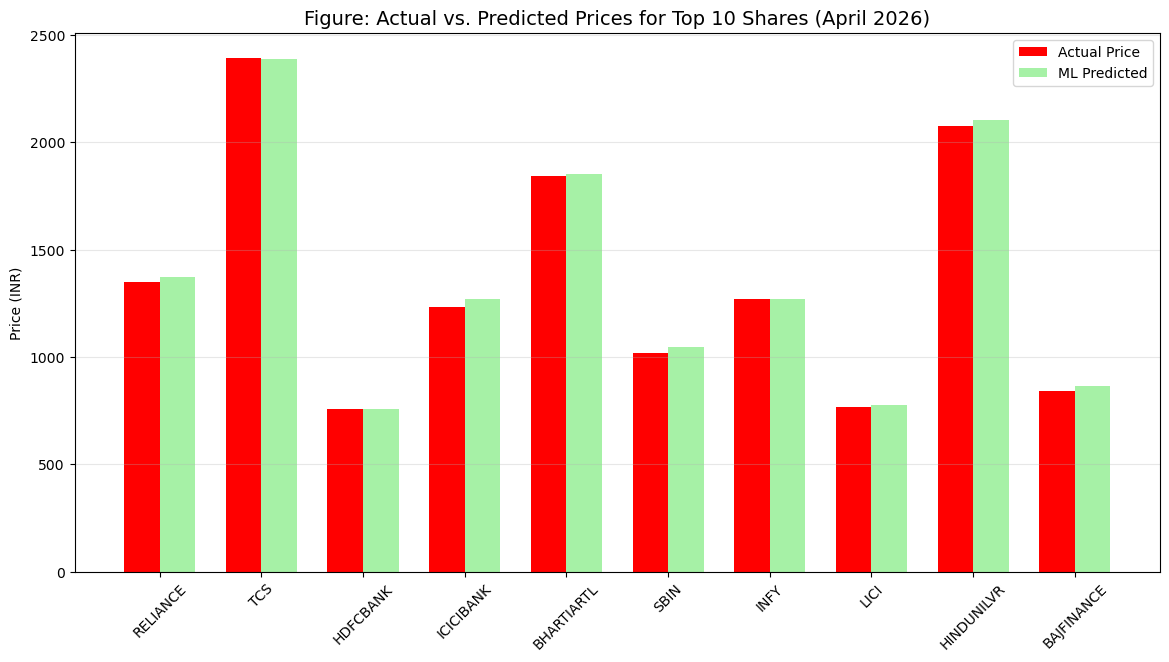

In [60]:
# 1. Define Top 10 Tickers (Based on April 2026 Market Cap)
tickers = [
    'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'BHARTIARTL.NS', 
    'SBIN.NS', 'INFY.NS', 'LICI.NS', 'HINDUNILVR.NS', 'BAJFINANCE.NS'
]

def build_and_predict(symbol):
    # Fetch historical data for training (2500+ records)
    df = yf.download(symbol, start='2016-01-01', end='2026-04-01', progress=False)
    
    # Feature Engineering
    df['MA50'] = df['Close'].rolling(window=50).mean()
    df['MA200'] = df['Close'].rolling(window=200).mean()
    df['Prev_Close'] = df['Close'].shift(1)
    df['Target'] = df['Close'].shift(-1)
    df.dropna(inplace=True)
    
    # ML Model Training
    features = ['Open', 'High', 'Low', 'Volume', 'MA50', 'MA200', 'Prev_Close']
    X = df[features]
    y = df['Target']
    
    # Train on past data, predict on the very last available record
    model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1)
    model.fit(X[:-1], y[:-1])
    
    # Get the latest "Actual" price and the "Predicted" price for tomorrow
    actual_price = df['Close'].iloc[-1]
    prediction = model.predict(X.tail(1))[0]
    
    return round(float(actual_price), 2), round(float(prediction), 2)

# 2. Execute Pipeline for all 10 Shares
results = []
print(f"Analyzing Market Data for {datetime.now().strftime('%Y-%m-%d')}...")

for t in tickers:
    try:
        act, pred = build_and_predict(t)
        results.append({
            'Ticker': t.replace('.NS', ''),
            'Actual_Price': act,
            'Predicted_Price': pred,
            'Difference': round(pred - act, 2),
            'Signal': 'BUY' if pred > act else 'SELL'
        })
    except Exception as e:
        print(f"Error processing {t}: {e}")

# 3. Create the Final Comparison Dataframe
final_df = pd.DataFrame(results)
print("\n--- FINAL ML COMPARISON FRAME ---")
print(final_df)

# 4. Final Visual: Actual vs Predicted Bar Chart
plt.figure(figsize=(14, 7))
x = np.arange(len(final_df['Ticker']))
width = 0.35

plt.bar(x - width/2, final_df['Actual_Price'], width, label='Actual Price', color='red')
plt.bar(x + width/2, final_df['Predicted_Price'], width, label='ML Predicted', color='lightgreen', alpha=0.8)

plt.title('Figure: Actual vs. Predicted Prices for Top 10 Shares (April 2026)', fontsize=14)
plt.xticks(x, final_df['Ticker'], rotation=45)
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()